In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

df = pd.read_csv('Student_Performance.csv')
X = df.drop(['student_id', 'math_score', 'science_score', 'english_score', 'overall_score', 'final_grade'], axis=1)
y = df['overall_score']

X_encoded = pd.get_dummies(X, drop_first=True)
joblib.dump(list(X_encoded.columns), 'model_features.pkl')

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

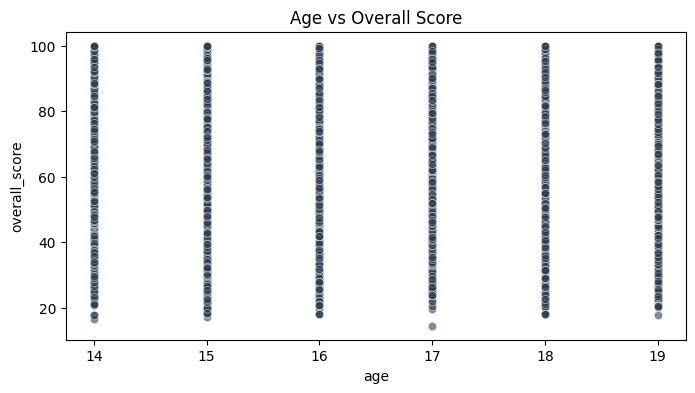

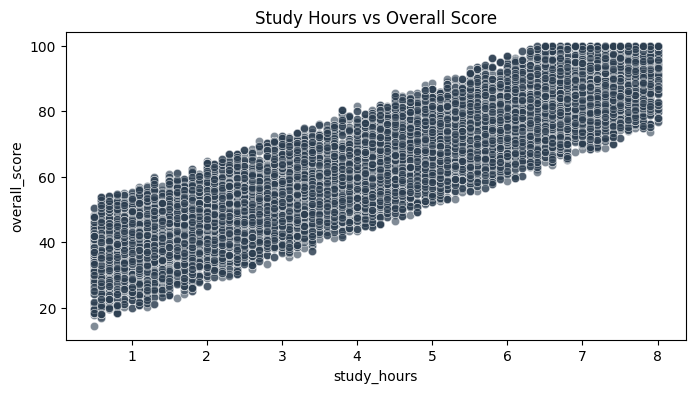

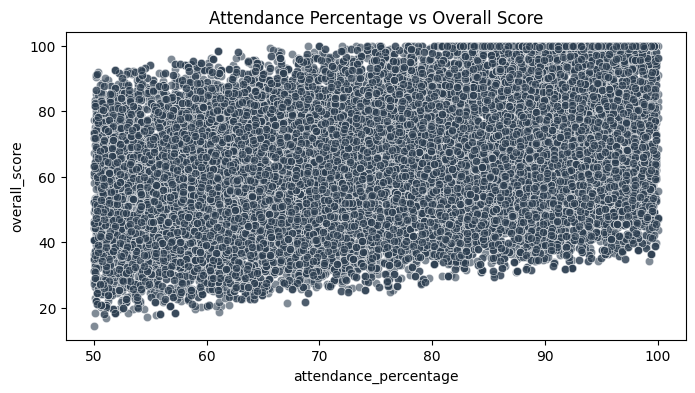

C:\Users\Anosh Dilshad\AppData\Local\Temp\ipykernel_16960\2519043523.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x=col, y=target, palette='viridis')


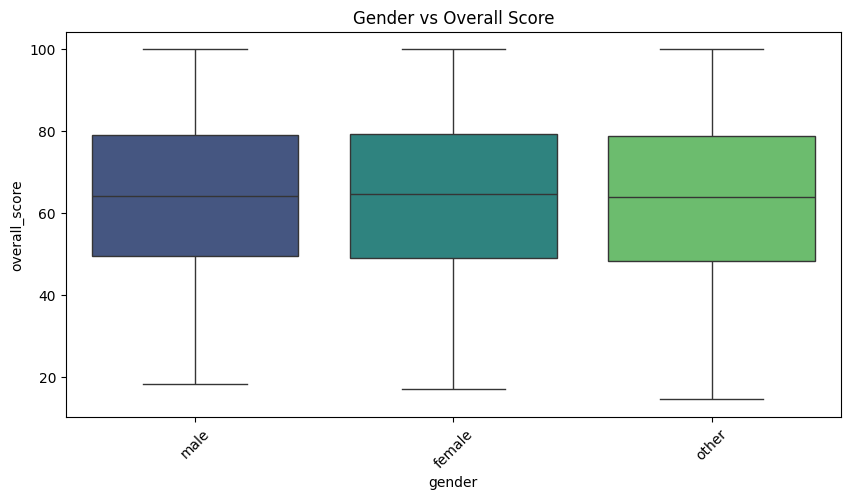

C:\Users\Anosh Dilshad\AppData\Local\Temp\ipykernel_16960\2519043523.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x=col, y=target, palette='viridis')


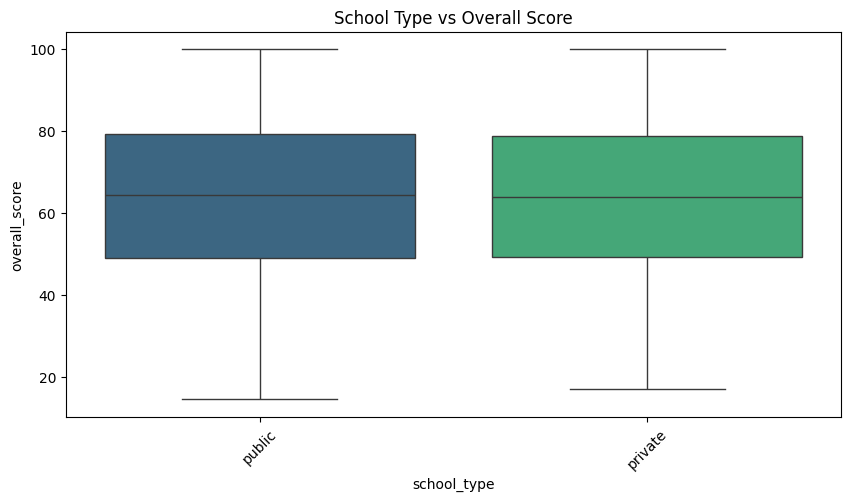

C:\Users\Anosh Dilshad\AppData\Local\Temp\ipykernel_16960\2519043523.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x=col, y=target, palette='viridis')


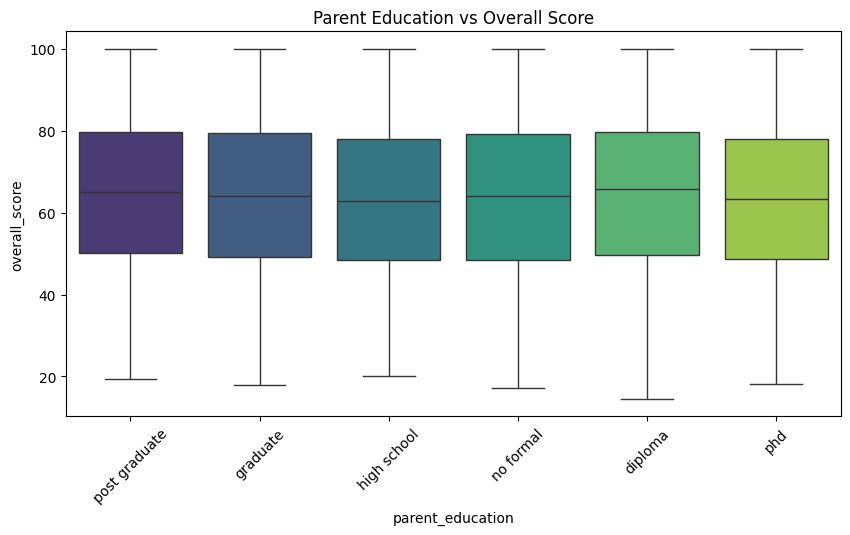

C:\Users\Anosh Dilshad\AppData\Local\Temp\ipykernel_16960\2519043523.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x=col, y=target, palette='viridis')


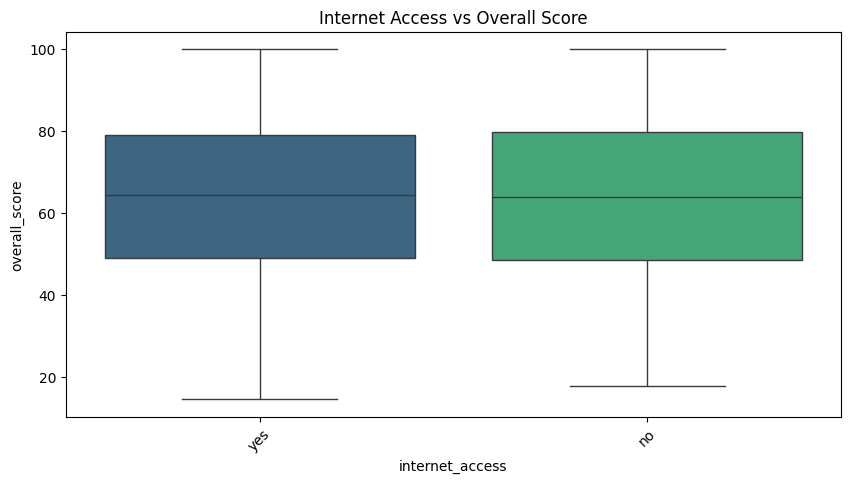

C:\Users\Anosh Dilshad\AppData\Local\Temp\ipykernel_16960\2519043523.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x=col, y=target, palette='viridis')


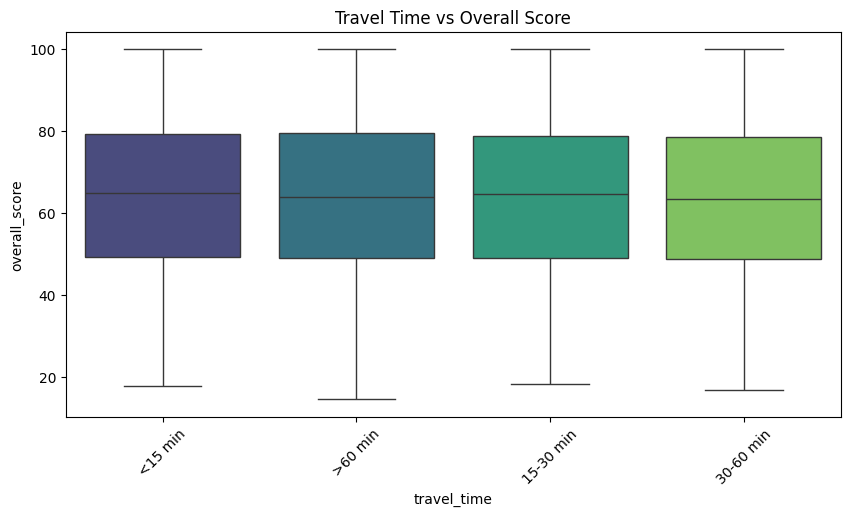

C:\Users\Anosh Dilshad\AppData\Local\Temp\ipykernel_16960\2519043523.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x=col, y=target, palette='viridis')


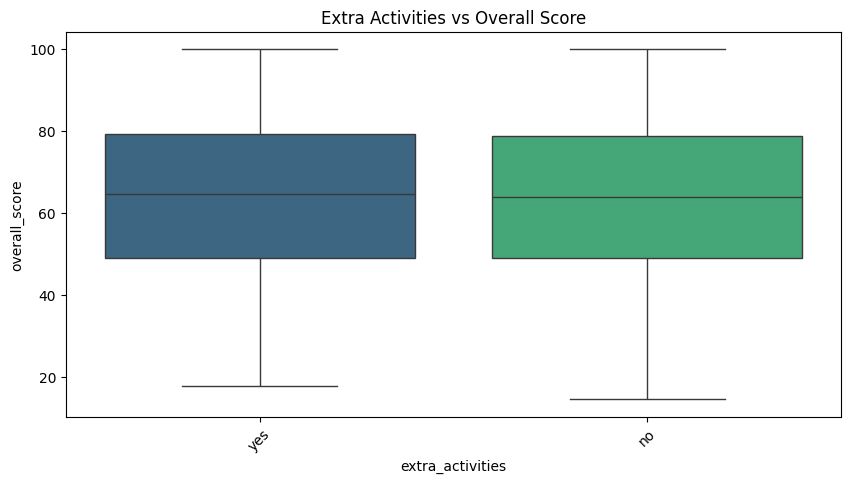

C:\Users\Anosh Dilshad\AppData\Local\Temp\ipykernel_16960\2519043523.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x=col, y=target, palette='viridis')


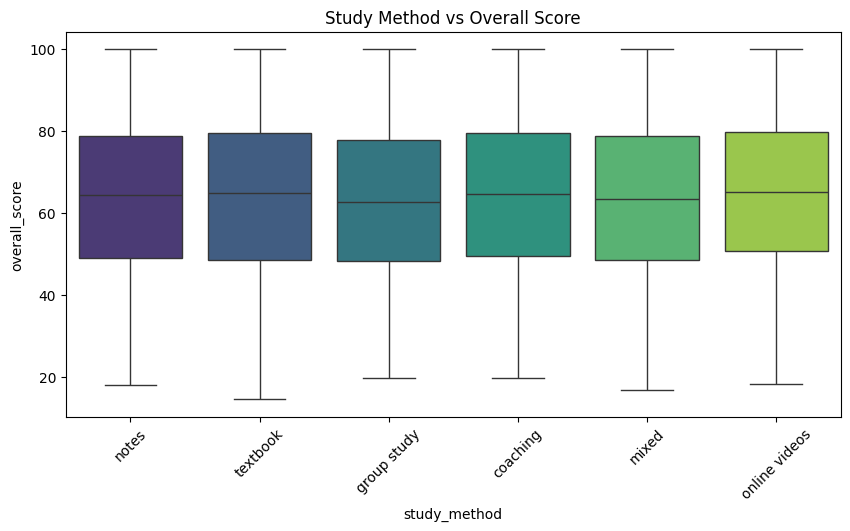

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df_eda = pd.read_csv('Student_Performance.csv')
target = 'overall_score'
df_eda = df_eda.drop(columns=['student_id', 'math_score', 'science_score', 'english_score', 'final_grade'])
num_cols = df_eda.select_dtypes(include=['float64', 'int64']).columns.drop(target)
cat_cols = df_eda.select_dtypes(include=['object']).columns

for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.scatterplot(data=df_eda, x=col, y=target, alpha=0.6, color='#2c3e50')
    plt.title(f'{col.replace("_", " ").title()} vs Overall Score')
    plt.show()

for col in cat_cols:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df_eda, x=col, y=target, palette='viridis')
    plt.title(f'{col.replace("_", " ").title()} vs Overall Score')
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train_scaled, y_train)
gb_pred = gb.predict(X_test_scaled)
print(f"Model Accuracy (R2 Score): {r2_score(y_test, gb_pred):.2f}")
joblib.dump(gb, 'student_model.pkl')

Model Accuracy (R2 Score): 0.91


['student_model.pkl']